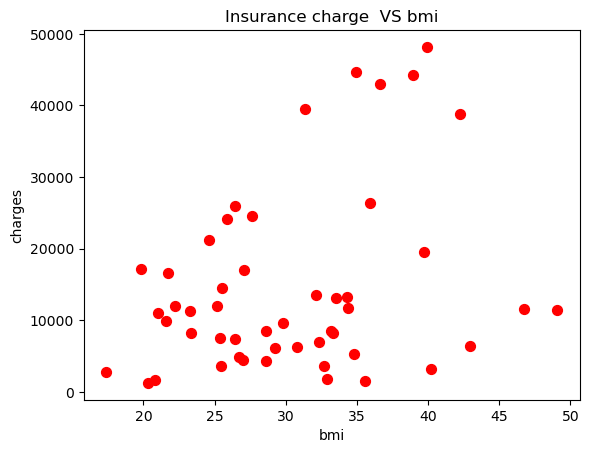

In [ ]:
#scatter plot 
import pandas as pd
import matplotlib.pyplot as plt

db = pd.read_csv("insurance.csv")
db_sample = db.sample(n=50)
db_sample.plot.scatter(x= 'bmi' , y= 'charges' , s=50 , c='red')
plt.title( 'Insurance charge  VS bmi');



In [43]:
db

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


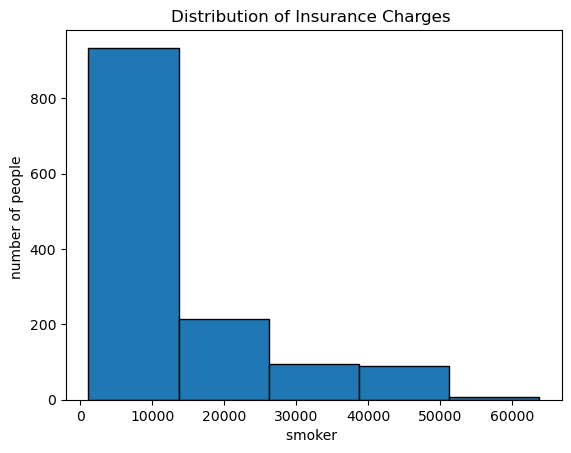

In [55]:
#histogram
import pandas as pd
import matplotlib.pyplot as plt

db = pd.read_csv("insurance.csv")

plt.hist(db['charges'], bins=5, edgecolor='black')

plt.xlabel('smoker ')
plt.ylabel('number of people ')
plt.title('Distribution of Insurance Charges ')

plt.show()



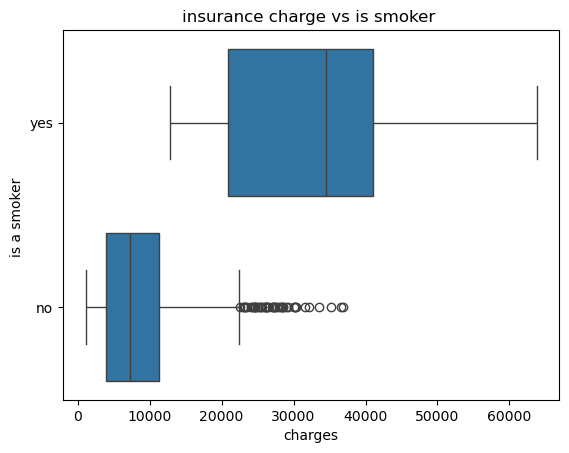

In [54]:
# boxplot 

import pandas as pd
import seaborn as sns 


db = pd.read_csv("insurance.csv")
sns.boxplot(x=db['charges'], y=db['smoker'])

plt.xlabel('charges')
plt.ylabel('is a smoker ')
plt.title('insurance charge vs is smoker ')

plt.show()


In [49]:
##question one descriptive sampling 
import pandas as pd
db = pd.read_csv("insurance.csv")
def Desc_stat(db, var):
    mean = db[var].mean()
    median = db[var].median()
    mode = db[var].mode()[0]
    minimum = db[var].min()
    maximum = db[var].max()
    range_val = maximum - minimum
    std_dev = db[var].std()
    variance = db[var].var()
    skew = db[var].skew()
    kurtosis = db[var].kurt()
    count = db[var].count()
    Quart = [
        db[var].quantile(0),
        db[var].quantile(0.25),
        db[var].quantile(0.50),
        db[var].quantile(0.75),
        db[var].quantile(1),
        db[var].quantile(0.75) - db[var].quantile(0.25)
    ]
    summary = {
        "Average": mean,
        "Median": median,
        "Mode": mode,
        "Minimum ": minimum,
        "Maximim ": maximum,
        "Range ": range,
        "Std Dev ": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "Minimum": Quart [0],
        "25th Pecentile": Quart[1],
        "50th Pecentile": Quart[2],
        "75th Pecentile ": Quart[3],
        "Maximum ": Quart[4],
        "Inter Quartile Range": Quart[5],
        "Count ": count
    }
    return summary

Desc_stat(db, 'charges')

{'Average': np.float64(13270.422265141257),
 'Median': 9382.033,
 'Mode': np.float64(1639.5631),
 'Minimum ': 1121.8739,
 'Maximim ': 63770.42801,
 'Range ': range,
 'Std Dev ': 12110.011236693996,
 'Variance': 146652372.15285483,
 'Skewness': np.float64(1.5158796580240388),
 'Kurtosis': np.float64(1.6062986532967907),
 'Minimum': np.float64(1121.8739),
 '25th Pecentile': np.float64(4740.28715),
 '50th Pecentile': np.float64(9382.033),
 '75th Pecentile ': np.float64(16639.912515),
 'Maximum ': np.float64(63770.42801),
 'Inter Quartile Range': np.float64(11899.625365),
 'Count ': np.int64(1338)}

In [48]:
# question two / random sampling
sample_db = db.sample(n=150 , replace=False , random_state = 42 )
Desc_stat(sample_db, 'charges')

{'Average': np.float64(13010.715697466665),
 'Median': 8702.9537,
 'Mode': np.float64(1131.5066),
 'Minimum ': 1131.5066,
 'Maximim ': 48673.5588,
 'Range ': range,
 'Std Dev ': 11916.853846001031,
 'Variance': 142011405.5869496,
 'Skewness': np.float64(1.3707268245383637),
 'Kurtosis': np.float64(0.9297571143413785),
 'Minimum': np.float64(1131.5066),
 '25th Pecentile': np.float64(4727.569912499999),
 '50th Pecentile': np.float64(8702.9537),
 '75th Pecentile ': np.float64(18179.9385),
 'Maximum ': np.float64(48673.5588),
 'Inter Quartile Range': np.float64(13452.368587500001),
 'Count ': np.int64(150)}

In [117]:
#systematic sampling

systematic_db = db.iloc[3 :: 4]
Desc_stat(systematic_db, 'charges')

{'Average': np.float64(13312.12533376946),
 'Median': 9609.21565,
 'Mode': np.float64(1136.3994),
 'Minimum ': 1136.3994,
 'Maximim ': 63770.42801,
 'Range ': range,
 'Std Dev ': 12136.307731356534,
 'Variance': 147289965.35018435,
 'Skewness': np.float64(1.5033947964298473),
 'Kurtosis': np.float64(1.7019437899815695),
 'Minimum': np.float64(1136.3994),
 '25th Pecentile': np.float64(4721.6722375),
 '50th Pecentile': np.float64(9609.21565),
 '75th Pecentile ': np.float64(17418.7826175),
 'Maximum ': np.float64(63770.42801),
 'Inter Quartile Range': np.float64(12697.110380000002),
 'Count ': np.int64(334)}

In [71]:
# hypothesis test 

# pearsons 
import pandas as pd 
from scipy.stats import pearsonr

db = pd.read_csv("insurance.csv")

db_clean = db.dropna(subset=['bmi', 'charges'])
r, _ = pearsonr(db_clean['bmi'], db_clean['charges'])
print(f"Pearson's Correlation Coefficient: {r:.4f}")

Pearson's Correlation Coefficient: 0.1983


In [75]:
# spearman test 

import pandas as pd 
from scipy.stats import spearmanr

db = pd.read_csv("insurance.csv")

db_clean = db.dropna(subset=[ 'charges', 'bmi'])

r, _=  spearmanr(db_clean[ 'charges'], db_clean[ 'bmi'])

print(f"Spearman's Correlation Coefficient: {r:.4f}")

Spearman's Correlation Coefficient: 0.1194


In [82]:
#chi-square test 
import pandas as pd
from scipy.stats import chi2_contingency

db = pd.read_csv("insurance.csv")

contingency_data = pd.crosstab(db['smoker'], db['region'])

r, p, dof, expected = chi2_contingency(contingency_data)

print('r=%.3f, p =%.3f' % (r, p))

if p > 0.05:
    print('Smoker status and Region are independent')
else:
    print('Smoker status and Region are dependent')

r=7.343, p =0.062
Smoker status and Region are independent


In [111]:
# one sample test 

import pandas as pd
from scipy.stats import shapiro

db = pd.read_csv('insurance.csv')

charges=db['charges']
print(db['charges'])
print(f'Average charge : ', db['charges'].mean() )


r, p = shapiro(db ['charges'] .dropna())
print('r=%.2f, p=%.3f' % (r,p) )

if p > 0.05:
    print ('Normal distribution' )
else:
    print ('Not a normal distribution')

import scipy
t_stat, p_ttest=scipy.stats.ttest_1samp(db['charges'].dropna(),75)

if p_ttest > 0.05:
    print(f'p value is greater then 0.05, null hypothesis is accepted')
else:
    print(f'p value is less then 0.05, null hypothesis is accepted')

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64
Average charge :  13270.422265141257
r=0.81, p=0.000
Not a normal distribution
p value is less then 0.05, null hypothesis is accepted


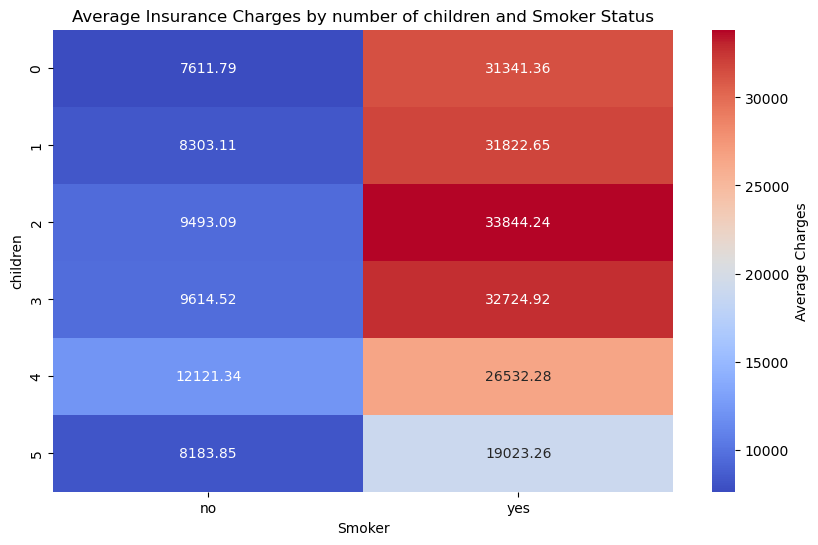

In [114]:
#HEAT MAP
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

file_path = 'insurance.csv'
insurance_data = pd. read_csv(file_path)

heatmap_data = insurance_data.pivot_table(
    index='children' ,
    columns='smoker',
    values='charges',
    aggfunc= 'mean'
)
plt.figure(figsize=(10,6))
sns. heatmap (
    heatmap_data, 
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Average Charges'}
)
plt.title( 'Average Insurance Charges by number of children and Smoker Status') 
plt.ylabel('children')
plt.xlabel ('Smoker')
plt.show()